# Machine Learning - CA 3
# Fruit Image Classification Using Deep Learning Models

Matthew Riddell - D00245674<br>
Albert Skalinski - D00248346

For this CA, we wish to look at doing a complex classification between fruits.<br>
We selected the following dataset from kaggle:<br>
https://www.kaggle.com/datasets/utkarshsaxenadn/fruits-classification
<br><br>
The dataset consists of 10,000 images of the following classes:
- Apples
- Bananas
- Grapes
- Mangoes
- Strawberries

This code is available on our github repo:<br>
https://github.com/Matthew-Riddell/Machine-Learning-CA3


#### Package Imports

In [3]:
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

#### Dataset folders

In [4]:
## Matthew's folder: "C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Machine Learning/CAs/CA3/Machine-Learning-CA3/dataset/"
## Albert's folder: "C:/Users/sKALa/Repos/Semester 2/Machine Learning/CAs/CA 3/Machine-Learning---CA-3/dataset/"

datasets_folder = "C:/Users/sKALa/Repos/Semester 2/Machine Learning/CAs/CA 3/Machine-Learning---CA-3/dataset/"
train_folder = datasets_folder + "training_set/training_set/"
test_folder = datasets_folder + "test_set/test_set/"

#### Loading the dataset and dividing the images into batches

loads the images from the folders and keras applies labels

resizes the images to 128x128 and takes them in batches of 32 images at a time

image_dataset_from_directory() then returns the count of x (images) and y (classes) which are apple, banana, grape, mango and strawberry

In [5]:
# https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_folder,
    image_size=(128, 128),
    batch_size=32
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_folder,
    image_size=(128, 128),
    batch_size=32
)

Found 9700 files belonging to 5 classes.
Found 100 files belonging to 5 classes.


#### Normalization

rescaling the pixels to be values between 0 and 1 so they work better in the neural network

the normalization is then applied to each image in the datasets via the x (image) and y (class) values 

In [6]:
# https://www.tensorflow.org/api_docs/python/tf/keras/layers/Rescaling

normalization = layers.Rescaling(1./255)
train_data = train_data.map(lambda x, y: (normalization(x), y))
test_data = test_data.map(lambda x, y: (normalization(x), y))

## Simple Machine Learning Models

### Baseline CNN Model

#### Making the CNN Model

here a simple sequential CNN model is made:

Input layer -> Convolutional Layer 1 -> Pooling Layer 1 -> Convolutional Layer 2 -> Pooling Layer 2 -> Flatten Layer -> Dense Layer -> Output Layer

The convolutional layers will use the ReLu activation function which outputs a 1 for positive inputs and 0 for negatives 

The final layer will use the softmax activation function which is the ideal activation function for multiple classes in a classification problem 



In [30]:
# https://www.tensorflow.org/guide/keras/sequential_model?hl=en

model1 = Sequential()

# Convolutional Layer 1
model1.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))

# Pooling Layer 1
model1.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional Layer 2
model1.add(Conv2D(64, (3,3), activation='relu'))

# Pooling Layer 2
model1.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model1.add(Flatten())

# Dense Layer
model1.add(Dense(64, activation='relu'))

# Output Layer
model1.add(Dense(5, activation='softmax'))

C:\Users\sKALa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Model Shape and Size

In [31]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,181 (14.14 MB)

 Trainable params: 3,706,181 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

#### Compiling the Model

preparing the model for training using the adam optimizer and using sparse cetegorical cross entropy as the loss function since it is a a multiple categorical classification

In [32]:
# https://www.tensorflow.org/api_docs/python/tf/keras/Model
# https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Training the Model

In [35]:
history1 = model1.fit(train_data, epochs=25)

Epoch 1/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 113s 372ms/step - accuracy: 0.5441 - loss: 1.1102
Epoch 2/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 109s 359ms/step - accuracy: 0.6339 - loss: 0.9222
Epoch 3/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 100s 327ms/step - accuracy: 0.7487 - loss: 0.6797
Epoch 4/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 100s 328ms/step - accuracy: 0.8461 - loss: 0.4278
Epoch 5/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 99s 326ms/step - accuracy: 0.9214 - loss: 0.2331
Epoch 6/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 100s 330ms/step - accuracy: 0.9587 - loss: 0.1294
Epoch 7/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 108s 356ms/step - accuracy: 0.9747 - loss: 0.0889
Epoch 8/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 95s 313ms/step - accuracy: 0.9749 - loss: 0.0801
Epoch 9/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 82s 270ms/step - accuracy: 0.9847 - loss: 0.0543
Epoch 10/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 83s 271ms/step - accuracy: 0.9835 - loss: 0.0578
Epoch 11/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 104s 343ms/step - accuracy: 0.9849 - loss: 0.0524
Epoch 12/25


#### Testing and Evaluation based on Test Data

In [36]:
loss, acc = model1.evaluate(test_data)
print("Test accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.6000 - loss: 3.6745
Test accuracy: 0.6000000238418579


accuracy: 0.6200 - loss: 3.4271

average performance for this simple CNN

it is basically correct 62% of the time

### Expanded CNN Model

#### Making the CNN Model

this model has an extra 3rd convolutional and pooling layer

here an expanded sequential CNN model is made:

Input layer -> Convolutional Layer 1 -> Pooling Layer 1 -> Convolutional Layer 2 -> Pooling Layer 2 -> Convolutional Layer 3 -> Pooling Layer 3 -> Flatten Layer -> Dense Layer -> Output Layer

The convolutional layers will use the ReLu activation function which outputs a 1 for positive inputs and 0 for negatives 

The final layer will use the softmax activation function which is the ideal activation function for multiple classes in a classification problem 



In [37]:
# https://www.tensorflow.org/guide/keras/sequential_model?hl=en

model2 = Sequential()

# Convolutional Layer 1
model2.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))

# Pooling Layer 1
model2.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional Layer 2
model2.add(Conv2D(64, (3,3), activation='relu'))

# Pooling Layer 2
model2.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional Layer 3
model2.add(Conv2D(128, (3,3), activation='relu'))

# Pooling Layer 3
model2.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model2.add(Flatten())

# Dense Layer
model2.add(Dense(64, activation='relu'))

# Output Layer
model2.add(Dense(5, activation='softmax'))

#### Model Shape and Size

In [38]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,269 (6.48 MB)

 Trainable params: 1,699,269 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

#### Compiling the model 

In [39]:
# https://www.tensorflow.org/api_docs/python/tf/keras/Model
# https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Training the model

In [40]:
history2 = model2.fit(train_data, epochs=25)

Epoch 1/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 101s 327ms/step - accuracy: 0.4913 - loss: 1.1833
Epoch 2/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 87s 285ms/step - accuracy: 0.6102 - loss: 0.9550
Epoch 3/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 90s 296ms/step - accuracy: 0.6619 - loss: 0.8474
Epoch 4/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 88s 290ms/step - accuracy: 0.7138 - loss: 0.7250
Epoch 5/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 95s 313ms/step - accuracy: 0.7715 - loss: 0.5922
Epoch 6/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 90s 297ms/step - accuracy: 0.8390 - loss: 0.4355
Epoch 7/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 78s 257ms/step - accuracy: 0.8891 - loss: 0.3058
Epoch 8/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 79s 261ms/step - accuracy: 0.9237 - loss: 0.2176
Epoch 9/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 76s 251ms/step - accuracy: 0.9446 - loss: 0.1601
Epoch 10/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 89s 293ms/step - accuracy: 0.9635 - loss: 0.1100
Epoch 11/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 97s 319ms/step - accuracy: 0.9673 - loss: 0.0987
Epoch 12/25
304/30

#### Testing and Evaluation of model on test data

In [41]:
loss, acc = model2.evaluate(test_data)
print("Test accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.7000 - loss: 2.6742
Test accuracy: 0.699999988079071


accuracy: 0.6500 - loss: 3.2067

average performance for this extended CNN model

it is basically correct 65% of the time

compared to the first model this is a very slight improvment

### Comparing the accuracy of Both Models

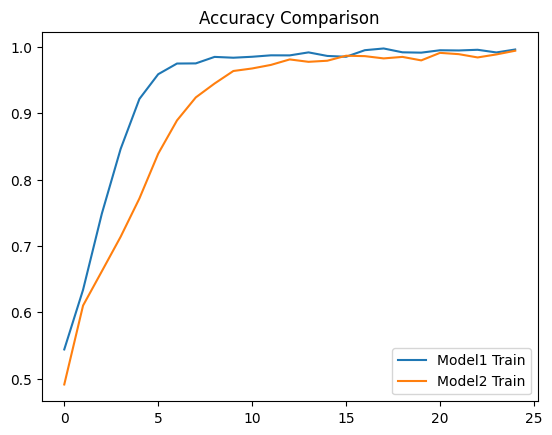

In [42]:
plt.plot(history1.history['accuracy'], label='Model1 Train')
plt.plot(history2.history['accuracy'], label='Model2 Train')

plt.legend()
plt.title("Accuracy Comparison")
plt.show()

## Complex ML Models

The code below is based on the following activities from Moodle:
- TL_EX1
- TL with VGG_Overview

### Importing Libraries

In [21]:
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from keras.models import Model

from keras.applications.vgg16 import VGG16
from keras import layers, models
from keras.callbacks import EarlyStopping

### MobileNetV2

**Creating the model**

In [17]:
# Declaring the model
model3 = MobileNetV2(weights = "imagenet", include_top = False, input_shape = (128, 128, 3))

# Freezing the pre-trained MobileNetV2 layers
model3.trainable = False

# Declaring inputs
inputs = Input(shape = (128, 128, 3))

# Pre-processing inputs for MobileNetV2
x = inputs

# Passing images through the pre-trained base model
x = model3(x, training = False)

# Converting feature maps into a single feature vector
x = GlobalAveragePooling2D()(x)

# Reducing overfitting by adding a Dropout layer
x = Dropout(0.3)(x)

# Declaring 5 output classes
outputs = Dense(5, activation = "softmax")(x)

# Final model
model3 = Model(inputs, outputs)

model3.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Compiling the model**

In [18]:
model3.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

**Training the model**

In [19]:
history3 = model3.fit(train_data, epochs = 25)

Epoch 1/25


304/304 ━━━━━━━━━━━━━━━━━━━━ 110s 350ms/step - accuracy: 0.7098 - loss: 0.7952
Epoch 2/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 103s 338ms/step - accuracy: 0.8186 - loss: 0.4985
Epoch 3/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 116s 381ms/step - accuracy: 0.8347 - loss: 0.4426
Epoch 4/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 110s 360ms/step - accuracy: 0.8471 - loss: 0.4188
Epoch 5/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 102s 334ms/step - accuracy: 0.8526 - loss: 0.4027
Epoch 6/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 93s 306ms/step - accuracy: 0.8607 - loss: 0.3920
Epoch 7/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 94s 308ms/step - accuracy: 0.8577 - loss: 0.3863
Epoch 8/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 95s 311ms/step - accuracy: 0.8709 - loss: 0.3708
Epoch 9/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 94s 310ms/step - accuracy: 0.8631 - loss: 0.3786
Epoch 10/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 93s 306ms/step - accuracy: 0.8619 - loss: 0.3740
Epoch 11/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 91s 298ms/step - accuracy: 0.8680 - loss: 0.3678
Epoch 12/25
304/304 ━━━━━

**Evaluating the model**

In [20]:
testLoss3, testAcc3 = model3.evaluate(test_data)

print("MobileNetV2 Test Accuracy:", testAcc3)
print("MobileNetV2 Test Loss:", testLoss3)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 253ms/step - accuracy: 0.9200 - loss: 0.2892
MobileNetV2 Test Accuracy: 0.9200000166893005
MobileNetV2 Test Loss: 0.2892153859138489


### VGG16

**Creating the model**

In [22]:
# Loading the pre-trained VGG16 model
model4 = VGG16(weights = "imagenet", include_top = False, input_shape = (128, 128, 3))

# Freezing the pre-trained convolutional base
model4.trainable = False

# Adding new classification layers
flattenLayer = layers.Flatten()
denseLayer1 = layers.Dense(50, activation = "relu")
denseLayer2 = layers.Dense(20, activation = "relu")
predictionLayer = layers.Dense(5, activation = "softmax")

# Building the model
model4 = models.Sequential([model4, flattenLayer, denseLayer1, denseLayer2, predictionLayer])

model4.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │       409,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,125,463 (57.70 MB)

 Trainable params: 410,775 (1.57 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

**Compiling the model**

In [23]:
model4.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

**Training the model**

In [24]:
earlyStopping = EarlyStopping(monitor = "accuracy", mode = "max", patience = 3, restore_best_weights = True)

history4 = model4.fit(train_data, epochs = 25, callbacks = [earlyStopping])

Epoch 1/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 264s 850ms/step - accuracy: 0.6510 - loss: 0.9486
Epoch 2/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 255s 837ms/step - accuracy: 0.7639 - loss: 0.6515
Epoch 3/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 279s 916ms/step - accuracy: 0.8224 - loss: 0.5042
Epoch 4/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 263s 862ms/step - accuracy: 0.8611 - loss: 0.3919
Epoch 5/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 252s 827ms/step - accuracy: 0.8904 - loss: 0.3121
Epoch 6/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 256s 842ms/step - accuracy: 0.9233 - loss: 0.2288
Epoch 7/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 255s 839ms/step - accuracy: 0.9437 - loss: 0.1771
Epoch 8/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 254s 835ms/step - accuracy: 0.9573 - loss: 0.1358
Epoch 9/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 256s 841ms/step - accuracy: 0.9692 - loss: 0.0993
Epoch 10/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 256s 842ms/step - accuracy: 0.9754 - loss: 0.0808
Epoch 11/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 262s 860ms/step - accuracy: 0.9837 - loss: 0.0591
Epoch 12

**Evaluating the model**

In [25]:
testLoss4, testAccuracy4 = model4.evaluate(test_data)

print("VGG16 Test Accuracy:", testAccuracy4)
print("VGG16 Test Loss:", testLoss4)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 626ms/step - accuracy: 0.7900 - loss: 1.0898
VGG16 Test Accuracy: 0.7900000214576721
VGG16 Test Loss: 1.0897835493087769


## Metrics Evaluation

In [48]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

class_names = ["apples", "bananas", "grapes", "mangoes", "strawberries"]

def getPredictions(model, dataset):
    yTest = []
    yPred = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        predicted_labels = np.argmax(predictions, axis=1)

        yTest.extend(labels.numpy())
        yPred.extend(predicted_labels)

    return np.array(yTest), np.array(yPred)

In [49]:
def evaluateModel(name, yTest, yPred):
    print(f"\n{name}")
    print("-" * 50)

    print("Confusion Matrix:")
    print(confusion_matrix(yTest, yPred))

    print("\nClassification Report:")
    print(classification_report(yTest, yPred, target_names=class_names))

In [50]:
yTest, yPredBaseline = getPredictions(model1, test_data)
evaluateModel("Baseline CNN", yTest, yPredBaseline)

yTest, yPredExpanded = getPredictions(model2, test_data)
evaluateModel("Expanded CNN", yTest, yPredExpanded)

yTest, yPredMobileNet = getPredictions(model3, test_data)
evaluateModel("MobileNetV2", yTest, yPredMobileNet)

yTest, yPredVGG16 = getPredictions(model4, test_data)
evaluateModel("VGG16", yTest, yPredVGG16)


Baseline CNN
--------------------------------------------------
Confusion Matrix:
[[ 9  2  4  1  4]
 [ 0 13  2  5  0]
 [ 1  3 14  1  1]
 [ 2  3  2 12  1]
 [ 5  1  2  0 12]]

Classification Report:
              precision    recall  f1-score   support

      apples       0.53      0.45      0.49        20
     bananas       0.59      0.65      0.62        20
      grapes       0.58      0.70      0.64        20
     mangoes       0.63      0.60      0.62        20
strawberries       0.67      0.60      0.63        20

    accuracy                           0.60       100
   macro avg       0.60      0.60      0.60       100
weighted avg       0.60      0.60      0.60       100


Expanded CNN
--------------------------------------------------
Confusion Matrix:
[[12  3  1  2  2]
 [ 1 16  0  3  0]
 [ 2  0 15  2  1]
 [ 2  3  2 13  0]
 [ 4  1  1  0 14]]

Classification Report:
              precision    recall  f1-score   support

      apples       0.57      0.60      0.59        20
     b